In [13]:
import pandas as pd

df = pd.read_csv("http://114.207.245.181:13000/csv/iris01.csv")
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
t1 = dict(zip(df.columns, ['꽃받침길이', '꽃받침넓이', '꽃잎길이', '꽃잎넓이', '종류']))

In [15]:
df1 = df.rename(columns=t1)

In [16]:
df1

,꽃받침길이,꽃받침넓이,꽃잎길이,꽃잎넓이,종류
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [17]:
df1['종류'].value_counts()

종류
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [ ]:

df1['종류'] = df1['종류'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2})

In [19]:
df1.dtypes

꽃받침길이    float64
꽃받침넓이    float64
꽃잎길이     float64
꽃잎넓이     float64
종류         int64
dtype: object

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn_cjk import patch
patch()

sns.pairplot(data=df1, hue='종류')
plt.show()

In [27]:
x = df1[['꽃받침길이', '꽃받침넓이', '꽃잎길이', '꽃잎넓이']].values
y = df1['종류'].values
x.shape, y.shape

((150, 4), (150,))

In [ ]:
# 8:2 split
# 의사결정트리는 스케일이 필요없음
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=123, train_size=0.8)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120,), (30,))

In [29]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
model.score(x_train, y_train), model.score(x_test, y_test)

(1.0, 0.9666666666666667)

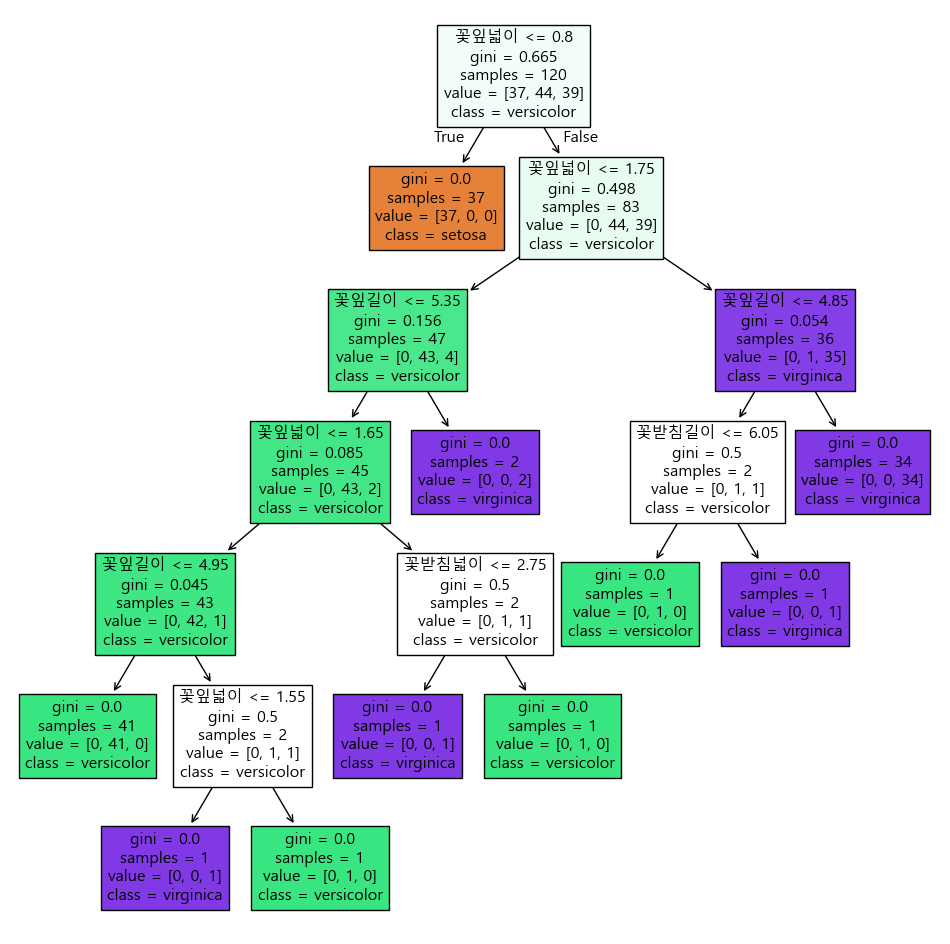

In [43]:
import matplotlib.pyplot as plt
from seaborn_cjk import patch
from sklearn import tree

patch()

fn = ['꽃받침길이', '꽃받침넓이', '꽃잎길이', '꽃잎넓이', '종류'] # 특정정보
cn = ['setosa', 'versicolor', 'virginica'] # 타겟정보

plt.figure(figsize=(12,12))
tree.plot_tree(model, filled=True, feature_names=fn, class_names=cn)
plt.show()

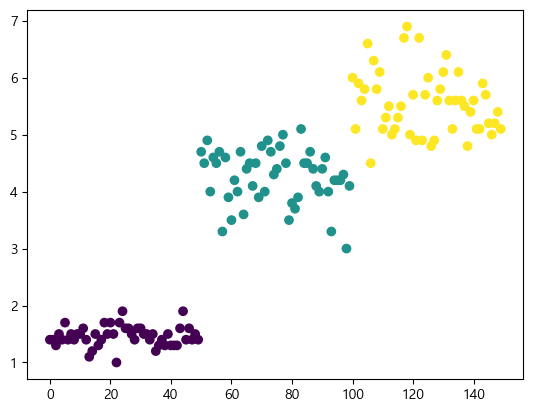

In [42]:
import matplotlib.pyplot as plt
from seaborn_cjk import patch

patch()

plt.scatter(df1.index, df1['꽃잎길이'], c=df1['종류'])
plt.show()

In [44]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [ ]:
# 그리드 서치
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=123),
    param_grid=param_grid,
    cv = 5, # 교차검증 5분할후에 1 2 3 4 5
    n_jobs = -1,
    verbose=2
)

grid_search.fit(x_train, y_train)
grid_search.best_params_, grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits


({'max_depth': None,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2},
 DecisionTreeClassifier(max_features='sqrt', random_state=123))

In [51]:
from sklearn.ensemble import RandomForestClassifier

# 의사결정트리를 100개 사용함
model = RandomForestClassifier(n_estimators=1000)
model.fit(x_train, y_train)
model.score(x_train, y_train), model.score(x_test, y_test)



(1.0, 0.9666666666666667)

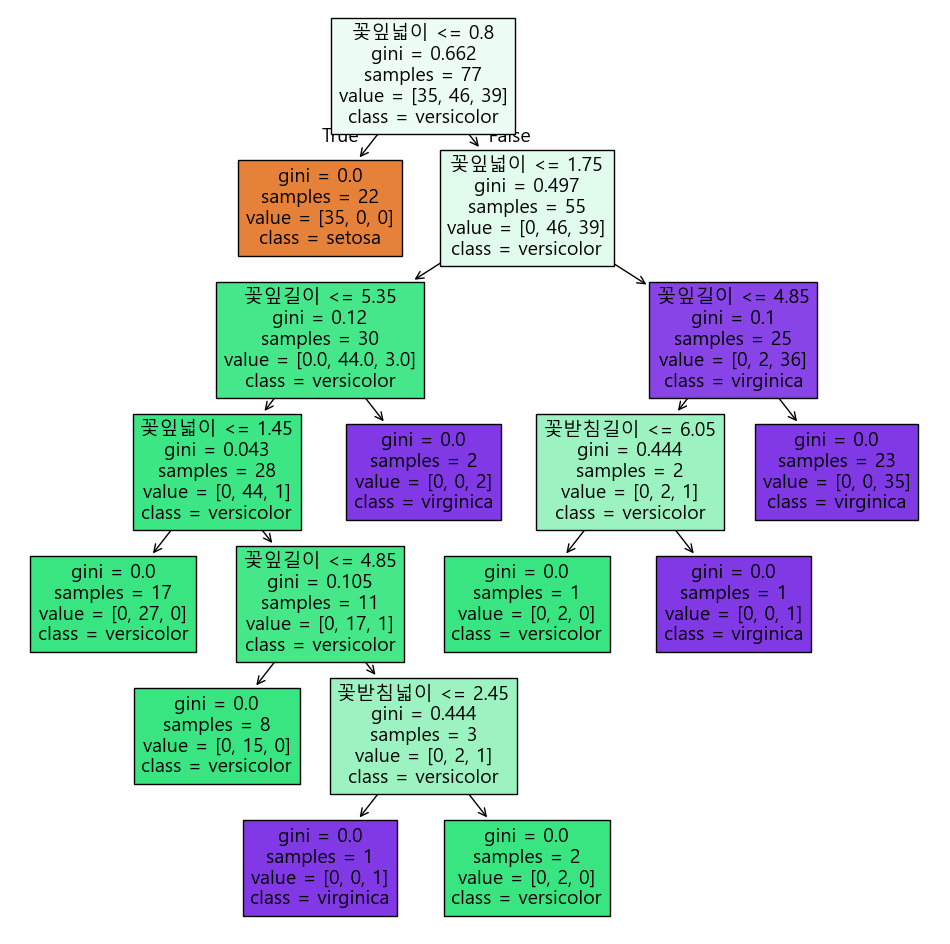

In [52]:
import matplotlib.pyplot as plt
from seaborn_cjk import patch
from sklearn import tree

patch()

fn = ['꽃받침길이', '꽃받침넓이', '꽃잎길이', '꽃잎넓이', '종류'] # 특정정보
cn = ['setosa', 'versicolor', 'virginica'] # 타겟정보

plt.figure(figsize=(12,12))
tree.plot_tree(model.estimators_[0], filled=True, feature_names=fn, class_names=cn)
plt.show()